In [1]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict

In [2]:
class BMIState(TypedDict):
    wgt_kg:float
    hgt_m: float
    bmi: float
    category: str

In [3]:
def cal_bmi(state: BMIState) -> BMIState:
    wgt = state['wgt_kg']
    hgt = state['hgt_m']
    bmi = wgt/(hgt**2)
    state['bmi'] = round(bmi, 2)
    return state

def category_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        category = "Underweight"
    elif 18.5 <= bmi < 24.9:
        category = "Normal weight"
    elif 25 <= bmi < 29.9:
        category = "Overweight"
    else:
        category = "Obese"

    state['category'] = category
    return state

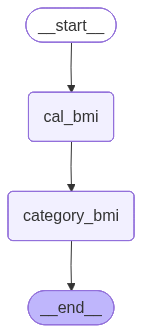

In [4]:
graph = StateGraph(BMIState)
graph.add_node('cal_bmi', cal_bmi)
graph.add_node('category_bmi', category_bmi)
graph.add_edge(START, 'cal_bmi')
graph.add_edge('cal_bmi', 'category_bmi')
graph.add_edge('category_bmi', END)
wfs = graph.compile()
wfs

In [5]:
wfs.invoke({'wgt_kg':79.5, 'hgt_m':1.702})

{'wgt_kg': 79.5, 'hgt_m': 1.702, 'bmi': 27.44, 'category': 'Overweight'}